## Position of a star

You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) 
- Compare it with the MLE estimator derived above

In [51]:
import numpy as np
from matplotlib import pyplot as plt
import scipy.stats
from scipy.stats import norm

In [52]:
#La pdf vera la assumiamo una gaussiana omoschedastica con mu = 1 e sigma = 0.2.
N = 10
true_mean = 1
true_sigma = 0.2

rng_samples = np.zeros(N)
rng_samples = scipy.stats.norm.rvs(loc =  true_mean, scale = true_sigma,size = N)  #estraiamo N rng samples dalla misure.


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Martina\AppData\Local\Temp\ipykernel_16844\4118822092.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


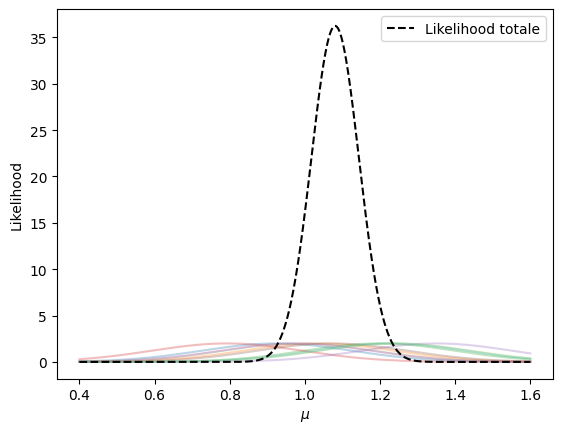

In [53]:
mu_ax = np.linspace(0.4, 1.6, 1000) #la griglia del parametro NB: in quesot caso la gaussiana ha x - mu al quadrato quindi è lo stesso procedimento se invertissimo

#single samples likelihood
single_likelihood = np.array([scipy.stats.norm.pdf(mu_ax, loc = sample, scale = true_sigma) for sample in rng_samples])

total_likelihood = np.prod(single_likelihood, axis = 0)

for sl in single_likelihood:
    plt.plot(mu_ax, sl, ls = '-', alpha = 0.3)

plt.plot(mu_ax, total_likelihood, ls = '--', color = 'black', label ='Likelihood totale')
plt.legend()
plt.xlabel('$\mu$')
plt.ylabel('Likelihood')
plt.savefig("./Images/EX_4_SinglevsTotal.png")

plt.show()

In [54]:
#Troviamo il massimo della likelihood, usiamo il suggerimento dell'esercizio di np.argsort
#https://numpy.org/devdocs/reference/generated/numpy.argsort.html

#Perform an indirect sort along the given axis using the algorithm specified by the kind keyword. 
#It returns an array of indices of the same shape as a that index data along the given axis in sorted order.


sorted_lh = np.argsort(total_likelihood)[::-1] #per ribaltare l'array e averlo in ordine decrescente

MLE_value = mu_ax[sorted_lh[0]]

print(f"{MLE_value} +- {true_sigma/np.sqrt(N)} contro il valore reale di {true_mean}")

1.0810810810810811 +- 0.06324555320336758 contro il valore reale di 1


### Part 2

Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees) 

In [55]:
#https://numpy.org/doc/stable/reference/generated/numpy.diff.html
#Calculate the n-th discrete difference along the given axis.

log_lh = np.log(total_likelihood)

sigma_diff = np.diff(log_lh, n =2) # n = The number of times values are differenced. 
sigma_diff = sigma_diff/(mu_ax[1]-mu_ax[0])**2 #dividiamo per il passo della griglia
sigma_diff = sigma_diff * (-1) #matrice di Fisher (in questo caso ho solo un parametro)
sigma_diff = 1/np.sqrt(sigma_diff)[0] #facciamo l'inversione della sqrt)

print(f"Con la matrice di Fisher ottengo {sigma_diff}, l'errore ottenuto prima era {true_sigma/np.sqrt(N)}, per una differenza di \n {np.abs(sigma_diff - true_sigma/np.sqrt(N))}")


Con la matrice di Fisher ottengo 0.06324555320519734, l'errore ottenuto prima era 0.06324555320336758, per una differenza di 
 1.8297585668847205e-12


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Martina\AppData\Local\Temp\ipykernel_16844\4062707946.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


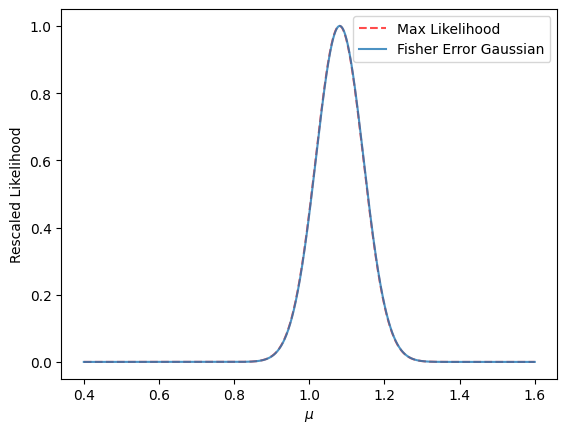

In [56]:
plt.plot(mu_ax, total_likelihood/np.max(total_likelihood), ls = '--', color = 'red', label = 'Max Likelihood', alpha = 0.7) #dividamo per i massimi per ottenere il rescaling
fisher_pdf =  scipy.stats.norm.pdf(mu_ax, loc =  MLE_value, scale = sigma_diff)
plt.plot(mu_ax,  fisher_pdf/np.max(fisher_pdf),label = 'Fisher Error Gaussian', alpha = 0.8)
plt.legend()
plt.xlabel('$\mu$')
plt.ylabel('Rescaled Likelihood')
plt.savefig("./Images/EX_4_FisherVsMax.png")
plt.show()


### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Martina\AppData\Local\Temp\ipykernel_16844\384854074.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


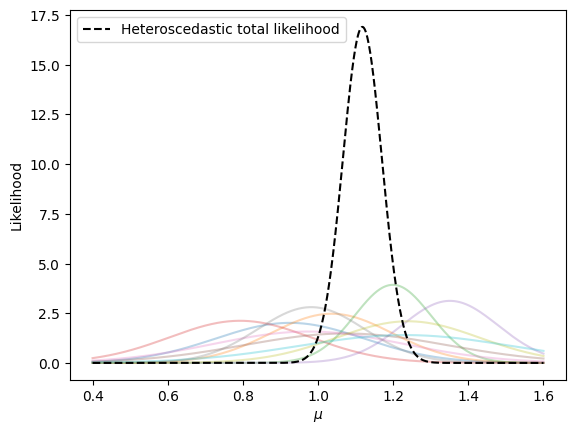

In [57]:
#Now is heteroschedastic
N = 10
true_mean = 1
true_sigmas = scipy.stats.norm.rvs(loc =  0.2, scale = 0.05, size = N) #generiamo le sigma con la distribuzione

mu_ax = np.linspace(0.4, 1.6, 1000) 

#single samples likelihood
single_likelihood = np.array([scipy.stats.norm.pdf(mu_ax, loc = sample, scale = sigma) for sample, sigma in zip(rng_samples, true_sigmas)]) #https://www.geeksforgeeks.org/python/zip-in-python/

total_likelihood = np.prod(single_likelihood, axis = 0)

for sl in single_likelihood:
    plt.plot(mu_ax, sl, ls = '-', alpha = 0.3)

plt.plot(mu_ax, total_likelihood, ls = '--', color = 'black', label = 'Heteroscedastic total likelihood')
plt.legend()
plt.xlabel('$\mu$')
plt.ylabel('Likelihood')
plt.savefig("./Images/EX_4_HETEROSinglevsTotal.png")
plt.show()


In [58]:
sorted_lh = np.argsort(total_likelihood)[::-1] #per ribaltare l'array e averlo in ordine decrescente

MLE_value = mu_ax[sorted_lh[0]]

sigma_MLE = np.sum(1./(true_sigmas**2))**(-0.5)

print(f"{MLE_value} +- {sigma_MLE} contro il valore reale di {true_mean}")

log_lh = np.log(total_likelihood)

sigma_diff = np.diff(log_lh, n =2) # n = The number of times values are differenced. 
sigma_diff = sigma_diff/(mu_ax[1]-mu_ax[0])**2 #dividiamo per il passo della griglia
sigma_diff = sigma_diff * (-1) #matrice di Fisher (in questo caso ho solo un parametro)
sigma_diff = 1/np.sqrt(sigma_diff)[0] #facciamo l'inversione della sqrt)

print(f"Con la matrice di Fisher ottengo {sigma_diff}, l'errore ottenuto prima era {sigma_MLE}, per una differenza di \n {np.abs(sigma_diff - sigma_MLE)}")



1.1183183183183183 +- 0.05204163261564834 contro il valore reale di 1
Con la matrice di Fisher ottengo 0.052041632616245094, l'errore ottenuto prima era 0.05204163261564834, per una differenza di 
 5.967518146299255e-13


<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Martina\AppData\Local\Temp\ipykernel_16844\498028150.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('$\mu$')


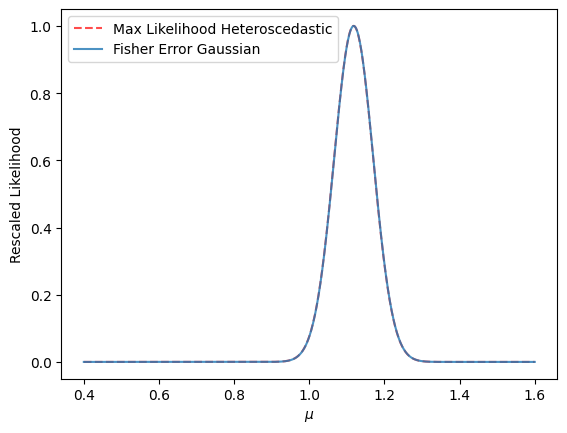

In [59]:
plt.plot(mu_ax, total_likelihood/np.max(total_likelihood), ls = '--', color = 'red', label = 'Max Likelihood Heteroscedastic' , alpha = 0.7) #dividamo per i massimi per ottenere il rescaling
fisher_pdf =  scipy.stats.norm.pdf(mu_ax, loc =  MLE_value, scale = sigma_diff)
plt.plot(mu_ax,  fisher_pdf/np.max(fisher_pdf),label = 'Fisher Error Gaussian', alpha = 0.8)
plt.legend()
plt.xlabel('$\mu$')
plt.ylabel('Rescaled Likelihood')
plt.savefig("./Images/EX_4_HETEROFisherVsMax.png")
plt.show()